In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:

df = pd.read_csv("data 2.csv")

# 1. Şarkı top 10'a girdi mi?
df['is_top10'] = df['pk'].apply(lambda x: 1 if x <= 10 else 0)


def categorize_pk(pk):
    if pk <= 10: return 'Top 10'
    elif pk <= 50: return 'Top 50'
    else: return 'Top 100+'
df['pk_tier'] = df['pk'].apply(categorize_pk)

# 3. Toplam dinlenmeye göre sınıflandırma
df['stream_tier'] = pd.qcut(df['total'], q=3, labels=['Düşük', 'Orta', 'Yüksek'])

sayisal_sutunlar = ['wks', 'pk', 'PkStreams', 'total']
kategorik_sutunlar = ['pk_tier', 'is_top10', 'stream_tier']

print(f"Veri seti: {df.shape[0]} satır, {df.shape[1]} sütun")
df.head()

Veri seti: 8058 satır, 13 sütun


,artist and title,wks,t10,pk,x?,PkStreams,total,artist name,song name,lyrics,is_top10,pk_tier,stream_tier
0,The Weeknd - Blinding Lights,347,64.0,1,(x13),52375259,5441240333,The Weeknd,Blinding Lights,Yeah I've been tryna call I've been on my own ...,1,Top 10,Yüksek
1,Ed Sheeran - Shape of You,424,34.0,1,(x14),64217796,4470842634,Ed Sheeran,Shape of You,The club isn't the best place to find a lover ...,1,Top 10,Yüksek
2,Harry Styles - As It Was,218,60.0,1,(x11),78460903,4417264164,Harry Styles,As It Was,﻿ As It Was - Harry Styles Come on Harry we wa...,1,Top 10,Yüksek
3,The Neighbourhood - Sweater Weather,333,NaN,16,NaN,21624450,4142643719,The Neighbourhood,Sweater Weather,And all I am is a man I want the world in my h...,0,Top 50,Yüksek
4,Lewis Capaldi - Someone You Loved,343,15.0,4,NaN,24962682,3933581891,Lewis Capaldi,Someone You Loved,I'm going under and this time I fear there's n...,1,Top 10,Yüksek


In [3]:
## Genel Bakış Özet

In [4]:
ozet = pd.DataFrame({
    "dtype": df.dtypes,
    "n_unique": df.nunique(),
    "eksik_değer":df.isnull().sum(),
    "eksik_değer_yüzdesi":(df.isnull().mean()*100).round(2)
})

ozet

,dtype,n_unique,eksik_değer,eksik_değer_yüzdesi
artist and title,object,7971,0,0.00
wks,int64,200,0,0.00
t10,float64,45,7248,89.95
pk,int64,239,0,0.00
x?,object,16,7724,95.86
PkStreams,int64,8057,0,0.00
total,int64,8058,0,0.00
artist name,object,1793,2,0.02
song name,object,7277,0,0.00
lyrics,object,7783,15,0.19


In [5]:
print("Tekrar eden satır:", df.duplicated().sum())

# Metin sütunlarındaki olası boşlukları temizleme
df["artist name"] = df["artist name"].astype(str).str.strip().str.title()
print(df["pk_tier"].value_counts())

Tekrar eden satır: 0
pk_tier
Top 100+    5043
Top 50      2205
Top 10       810
Name: count, dtype: int64


In [6]:
## **Betimsel İstatistik ve güven aralığı**

In [8]:
def ortalama_guven_araligi(seri, guven=0.95):
    veri = seri.dropna()
    n = len(veri)
    ortalama = veri.mean()
    sem = stats.sem(veri) # standart error of the mean
    t_kritik = stats.t.ppf((1+guven)/2, df=n-1)
    hata_payi = t_kritik * sem
    return ortalama, ortalama - hata_payi, ortalama + hata_payi

print(f"{'değişken':20s},{'Ortalama':>12s},{'%95 Alt':>12s},{'%95 Üst':>12s}")
for degisken in sayisal_sutunlar:
    ortalama, alt, ust = ortalama_guven_araligi(df[degisken])
    print(f"{degisken:20s},{ortalama:>12.2f},{alt:>12.2f},{ust:>12.2f}")

değişken            ,    Ortalama,     %95 Alt,     %95 Üst
wks                 ,       15.51,       14.84,       16.19
pk                  ,       83.66,       82.35,       84.98
PkStreams           , 11567261.20, 11343257.98, 11791264.43
total               ,141928030.10,134515637.16,149340423.03


In [9]:
betimsel = df[sayisal_sutunlar].describe().T
betimsel["skew"] = df[sayisal_sutunlar].skew()
betimsel["kurtosis"] = df[sayisal_sutunlar].kurtosis()
betimsel.round(2)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
wks,8058.0,1.551000e+01,3.092000e+01,1.0,1.00,4.0,1.700000e+01,4.570000e+02,5.67,48.66
pk,8058.0,8.366000e+01,6.013000e+01,1.0,30.00,74.0,1.320000e+02,2.460000e+02,0.40,-1.03
PkStreams,8058.0,1.156726e+07,1.025781e+07,166910.0,5368127.50,8941469.5,1.414555e+07,1.288961e+08,2.97,14.57
total,8058.0,1.419280e+08,3.394366e+08,166910.0,8916825.25,27980926.5,1.188043e+08,5.441240e+09,5.78,46.89


In [10]:
## **Normallik Testleri**

In [11]:
print(f"{'Değişken':20s} {'Shapiro-Wilk p':>16s} {'DAgostino p'} Yorum ")
for col in sayisal_sutunlar:
    veri= df[col].dropna()
    # shapiro n > 5000'den fazla olursa güvenilmez
    ornek = veri.sample(min(len(veri), 5000), random_state=0)
    sw_stat, sw_p = stats.shapiro(ornek)
    da_stat, da_p = stats.normaltest(veri)
    yorum = "Normal dağılım varsayımı sağlanmaktadır." if sw_p > 0.05 else "Normal dağılım varsayımı sağlanmamaktadır."
    print(f"{col:20s} {sw_p:>16.4f} {da_p:>16.4f} {yorum}")

Değişken               Shapiro-Wilk p DAgostino p Yorum 
wks                            0.0000           0.0000 Normal dağılım varsayımı sağlanmamaktadır.
pk                             0.0000           0.0000 Normal dağılım varsayımı sağlanmamaktadır.
PkStreams                      0.0000           0.0000 Normal dağılım varsayımı sağlanmamaktadır.
total                          0.0000           0.0000 Normal dağılım varsayımı sağlanmamaktadır.


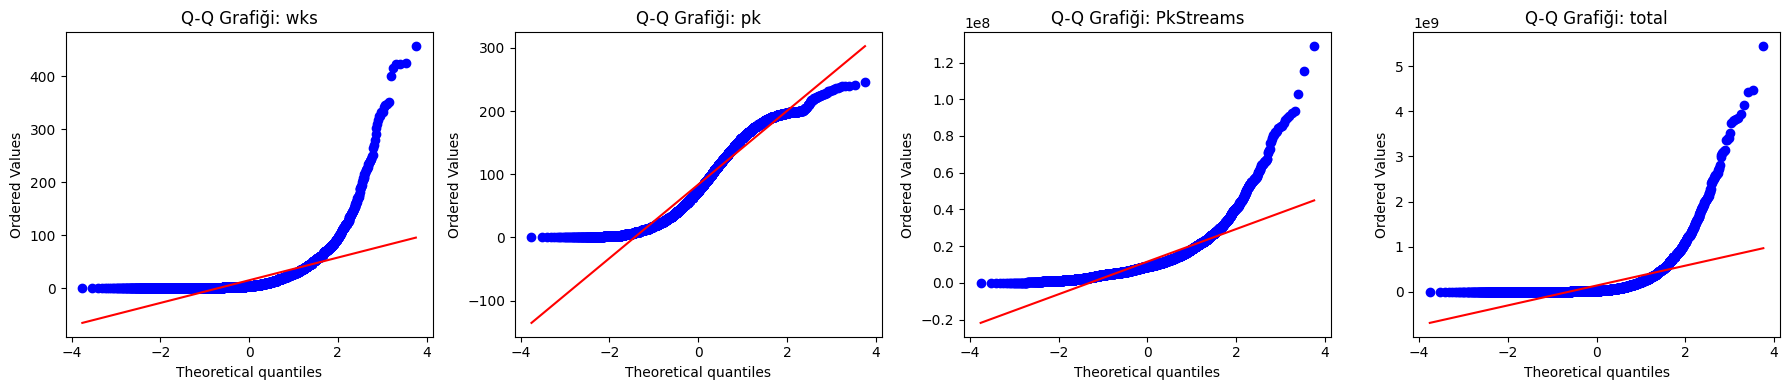

In [12]:
fig, axes = plt.subplots(1, len(sayisal_sutunlar), figsize=(18, 4))
for ax, col in zip(axes, sayisal_sutunlar):
    stats.probplot(df[col].dropna(), dist="norm", plot=ax)
    ax.set_title(f"Q-Q Grafiği: {col}")
plt.tight_layout()
plt.show()

In [13]:
## **İki Grup Karşılaştırması**

In [14]:
# Top 10'a girenler (is_top10=1) ve giremeyenlerin (0) Toplam Dinlenme Sayısı (total) Karşılaştırması
grup0 = df.loc[df["is_top10"] == 0 , "total"].dropna()
grup1 = df.loc[df["is_top10"] == 1, "total"].dropna()

levene_stat, levene_p = stats.levene(grup0, grup1)
print("Varsayımlar homojendir." if levene_p > 0.05 else "Varsayımlar homojen değildir.")

__, p0=stats.shapiro(grup0.sample(min(len(grup0),5000), random_state=0))
__, p1=stats.shapiro(grup1.sample(min(len(grup1),5000), random_state=0))
normal_mi = (p0 > 0.05) and (p1 > 0.05)
print(f"Grup normallik p değerleri: is_top10=0 -> {p0:.4f}, is_top10=1 -> {p1:.4f}")

Varsayımlar homojen değildir.
Grup normallik p değerleri: is_top10=0 -> 0.0000, is_top10=1 -> 0.0000


In [15]:
# **çoklu grup karşılaştırması**

In [16]:
gruplar = [g["total"].dropna().values for _, g in df.groupby("pk_tier")]

f_stat, anova_p = stats.f_oneway(*gruplar)
h_stat, kw_p = stats.kruskal(*gruplar)

print(f"Tek yönlü anova: f={f_stat:.3f}, p={anova_p:.4f}")
print(f"Kruskal-Wallis: h={h_stat:.3f}, p={kw_p:.4f}")

Tek yönlü anova: f=1760.269, p=0.0000
Kruskal-Wallis: h=3422.739, p=0.0000


In [17]:
genel_ortalama = df["total"].mean()
ss_between = sum(len(g) * (g.mean() - genel_ortalama)**2 for g in gruplar)
ss_total = sum((df["total"].dropna() - genel_ortalama)**2)
eta_kare = ss_between / ss_total
print(f"Eta Kare: {eta_kare:.4f} (0.01 küçük, 0.06 orta, 0.14 büyük etki)")

Eta Kare: 0.3041 (0.01 küçük, 0.06 orta, 0.14 büyük etki)


In [18]:
# Post-hoc analizi
tukey = pairwise_tukeyhsd(
    endog=df["total"].dropna(),
    groups=df.loc[df["total"].notna(), "pk_tier"],
    alpha=0.05
)

print(tukey)

             Multiple Comparison of Means - Tukey HSD, FWER=0.05              
 group1   group2      meandiff    p-adj      lower           upper      reject
------------------------------------------------------------------------------
  Top 10 Top 100+ -630374575.0202   0.0 -655502675.1523 -605246474.8881   True
  Top 10   Top 50 -487242797.0977   0.0 -514517136.2986 -459968457.8968   True
Top 100+   Top 50  143131777.9225   0.0  126183807.5229   160079748.322   True
------------------------------------------------------------------------------


In [19]:
## Kategorik Değişkenler Arasındaki İlişki

In [20]:
def cramers_v(x, y):
    tablo = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(tablo)[0]
    n = tablo.sum().sum()
    k = min(tablo.shape) - 1
    return np.sqrt(chi2 / (n * k))

capraz = pd.crosstab(df["pk_tier"], df["stream_tier"])
chi2, p, dof, beklenen = stats.chi2_contingency(capraz)
v = cramers_v(df["pk_tier"], df["stream_tier"])

print(f"chi2={chi2:.4f}, p={p:.4f}, v={v:.4f}")
print(f"Cramer's V: {v:.4f}")
print("\n Çapraz Tablo")
print(capraz)

chi2=3393.5841, p=0.0000, v=0.4589
Cramer's V: 0.4589

 Çapraz Tablo
stream_tier  Düşük  Orta  Yüksek
pk_tier                         
Top 10           0    44     766
Top 100+      2610  1725     708
Top 50          76   917    1212


In [21]:
## **Korelasyon Analizi**

In [22]:
def korelasyon_p_matrisi(veri, yontem="pearson"):
    sutunlar = veri.columns
    kat = pd.DataFrame(np.ones((len(sutunlar), len(sutunlar))), index=sutunlar, columns=sutunlar)
    pval = pd.DataFrame(np.zeros((len(sutunlar), len(sutunlar))), index=sutunlar, columns=sutunlar)
    for i in sutunlar:
        for j in sutunlar:
            if i == j:
                kat.loc[i,j] = 1.0
                pval.loc[i,j] = 0.0
                continue
            ortak = veri[[i,j]].dropna()
            x_seri, y_seri = ortak.iloc[:,0], ortak.iloc[:,1]
            if yontem == "pearson":
                r, p = stats.pearsonr(x_seri, y_seri)
            else:
                r, p = stats.spearmanr(x_seri, y_seri)
            kat.loc[i,j] = float(r)
            pval.loc[i,j] = float(p)
    return kat, pval

pearson_r, pearson_p = korelasyon_p_matrisi(df[sayisal_sutunlar], "pearson")
print("--- Pearson Korelasyon Katsayıları ---")
print(pearson_r)
print("\n--- Pearson p Değerleri ---")
print(pearson_p.round(4))

--- Pearson Korelasyon Katsayıları ---
                wks        pk  PkStreams     total
wks        1.000000 -0.404503   0.383219  0.892997
pk        -0.404503  1.000000  -0.625544 -0.404161
PkStreams  0.383219 -0.625544   1.000000  0.588607
total      0.892997 -0.404161   0.588607  1.000000

--- Pearson p Değerleri ---
           wks   pk  PkStreams  total
wks        0.0  0.0        0.0    0.0
pk         0.0  0.0        0.0    0.0
PkStreams  0.0  0.0        0.0    0.0
total      0.0  0.0        0.0    0.0


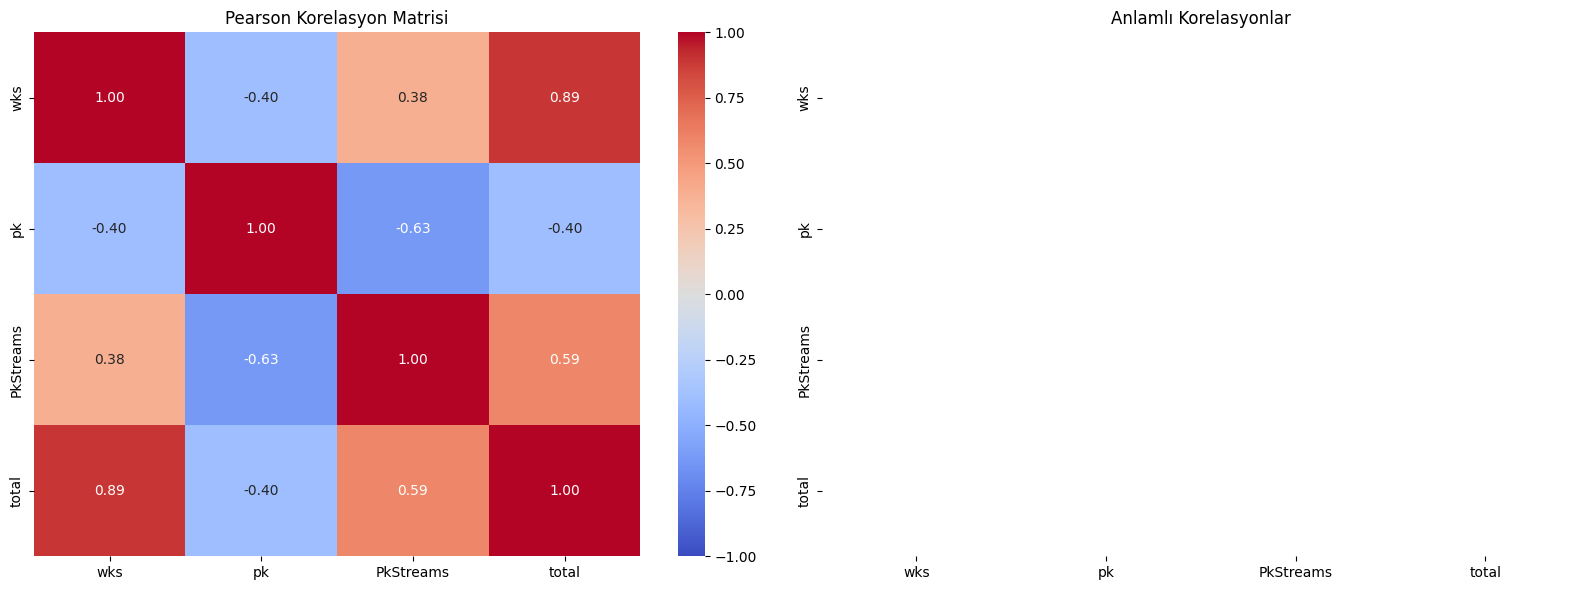

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))
sns.heatmap(pearson_r, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Pearson Korelasyon Matrisi")

anlamli_maske = pearson_p > 0.05

sns.heatmap(pearson_p, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, mask=~anlamli_maske, ax=axes[1], cbar=False)
axes[1].set_title("Anlamlı Korelasyonlar")
plt.tight_layout()
plt.show()

In [26]:
# Çoklu Doğrusal Bağlantı(Multicollinerity)
# * VIF < 5 sorun yok rahatız
# * 5 < VIF < 10 dikkat
# * VIF > 10  o değişkenlerle o iş olmaz

In [27]:
X_vif = df[["wks", "pk", "PkStreams"]].dropna()
X_vif_const = sm.add_constant(X_vif)

vif_tablosu = pd.DataFrame({
    "Değişken": [X_vif_const.columns[i] for i in range(1, X_vif_const.shape[1])],
    "VIF": [VIF(X_vif_const.values, i) for i in range(1, X_vif_const.shape[1])]
})
print(vif_tablosu)

    Değişken       VIF
0        wks  1.236806
1         pk  1.733503
2  PkStreams  1.699435


In [28]:
# **Keşifci Regresyon**

In [29]:
# total streams (Toplam Dinlenme) bağımlı değişken, wks (hafta) ve PkStreams bağımsız değişken
model_verisi = df[["total", "wks", "PkStreams"]].dropna()
model_verisi = sm.add_constant(model_verisi)
model = smf.ols(formula="total ~ wks + PkStreams", data=model_verisi)
sonuc = model.fit()
print(sonuc.summary())

                            OLS Regression Results                            
Dep. Variable:                  total   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.869
Method:                 Least Squares   F-statistic:                 2.662e+04
Date:                Mon, 21 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:20:31   Log-Likelihood:            -1.6154e+05
No. Observations:                8058   AIC:                         3.231e+05
Df Residuals:                    8055   BIC:                         3.231e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1.018e+08   2.07e+06    -49.218      0.0

In [30]:
## Temel Bileşenler Analizi(PCA)

In [31]:
pca_verisi = df[sayisal_sutunlar].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_verisi)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
aciklanan_varyans = pca.explained_variance_ratio_
print("Açıklanan Varyans Oranları:", aciklanan_varyans)

Açıklanan Varyans Oranları: [0.66576898 0.21768319 0.10130362 0.0152442 ]
